## Project 1 - Simulation and estimation in a Markov model of breast cancer

### Part 1: A discrete-time model

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy.stats import chi2
from scipy.linalg import expm
import scipy.stats as stats

In [6]:
# Transition matrix
P = np.array([
    [0.9915, 0.005,  0.0025, 0,     0.001],
    [0,      0.986,  0.005,  0.004, 0.005],
    [0,      0,      0.992,  0.003, 0.005],
    [0,      0,      0,      0.991, 0.009],
    [0,      0,      0,      0,     1.0]
])

# Number of states
n_states = 5

In [7]:
# we start by simulating one woman
def simulate_woman(P):

    """
    Returns:
        lifetime,
        first local recurrence (True/False),
        trajectory
    """

    # Initialize state
    state = 0  # State 1 in project notation
    lifetime = 0

    visited_local = False
    trajectory = [state]

    while state != 4: # State 5 = death

        prev = state
        state = np.random.choice(n_states, p=P[state])
        lifetime += 1
        trajectory.append(state)

        # Local recurrence (state 2 only)
        if (not visited_local) and (state == 1):
            visited_local = True

    return lifetime, visited_local, trajectory

### Task 1

Mean lifetime: 261.702
Median lifetime: 225.0
Std lifetime: 184.87219151619314
Proportion with local recurrence: 0.581
Number with local recurrence: 581 out of 1000


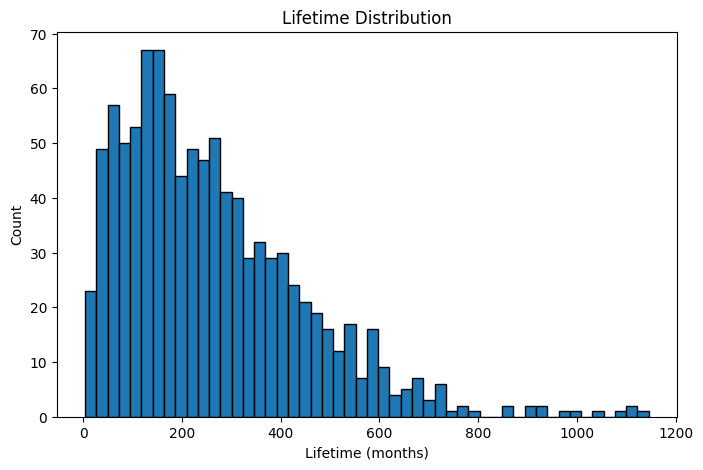

In [ ]:
# We now simulate 1000 women
n_women = 1000

# Simulate multiple women using the model
def simulate_multiple_women(P, n_women):

    lifetimes = []
    local_recurrence = []

    # Simulate n_women number of independent women
    for _ in range(n_women):

        life, local, _ = simulate_woman(P)

        lifetimes.append(life)
        local_recurrence.append(local)

    lifetimes = np.array(lifetimes)
    local_recurrence = np.array(local_recurrence)

    # Statistics
    print("Mean lifetime:", np.mean(lifetimes))
    print("Median lifetime:", np.median(lifetimes))
    print("Std lifetime:", np.std(lifetimes))

    # Proportion of women who experience local recurrence
    prop_local = np.mean(local_recurrence)
    num_local = np.sum(local_recurrence)

    print("Proportion with local recurrence:", prop_local)
    print("Number with local recurrence:", num_local, "out of", n_women)

    # Plot
    plt.figure(figsize=(8,5))
    plt.hist(lifetimes, bins=50, edgecolor = "black")
    plt.xlabel("Lifetime (months)")
    plt.ylabel("Count")
    plt.title("Lifetime Distribution")
    plt.show()

    return lifetimes, local_recurrence

lifetimes, local_recurrence = simulate_multiple_women(P, n_women)

### Task 2

In [ ]:
# Now we look at a specific t-value, t=120

n_women = 1000
t = 120

def specific_t(P, n_women):

    counts = np.zeros(5)

    for _ in range(n_women):

        # Initialize state
        state = 0

        for _ in range(t):

            state = np.random.choice(5,p=P[state])

        counts[state] += 1

    empirical = counts / n_women

    # Initialize the initial state distribution
    p0 = np.array([1,0,0,0,0])

    # Theoretical value
    theoretical = (p0@ np.linalg.matrix_power(P, t))

    print("Empirical:")
    print(empirical)

    print("\nTheoretical:")
    print(theoretical)

    # Chi-square GOF test
    expected_counts = (theoretical * n_women)

    print("\nExpected values:")
    print(expected_counts)

    print("\nObserved values:")
    print(counts)

    n_bins_chi2 = 5

    chi2_test = 0

    for i in range(n_bins_chi2):

        chi2_test += ((counts[i] - expected_counts[i])**2/expected_counts[i])

    df = n_bins_chi2 - 1

    p_val = (1-stats.chi2.cdf(x=chi2_test,df=df))

    print("\nChi-square GOF results:")
    print(f"df: {df}")
    print(f"test statistic: {chi2_test:.4f}")
    print(f"p-value: {p_val:.4f}")

    return empirical, theoretical, chi2_test, p_val


empirical, theoretical, chi2_test, p_val = specific_t(P, n_women)

Empirical:
[0.346 0.152 0.183 0.07  0.249]

Theoretical:
[0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]

Expected values:
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]

Observed values:
[346. 152. 183.  70. 249.]

Chi-square GOF results:
df: 4
test statistic: 2.5773
p-value: 0.6309


### Task 3

Theoretical PMF sum:
0.9985029227633535


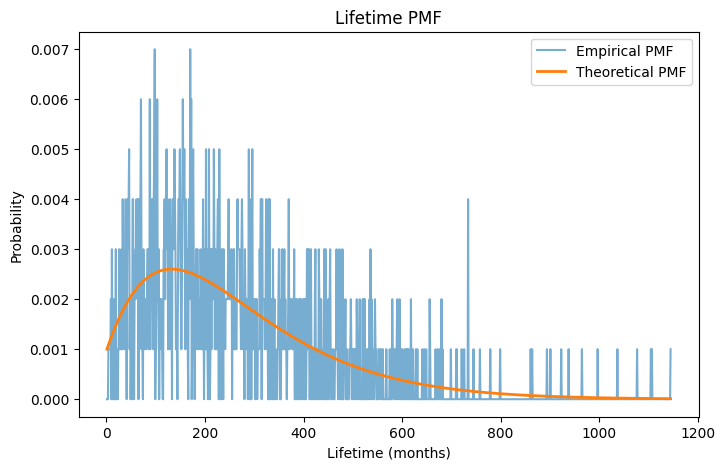

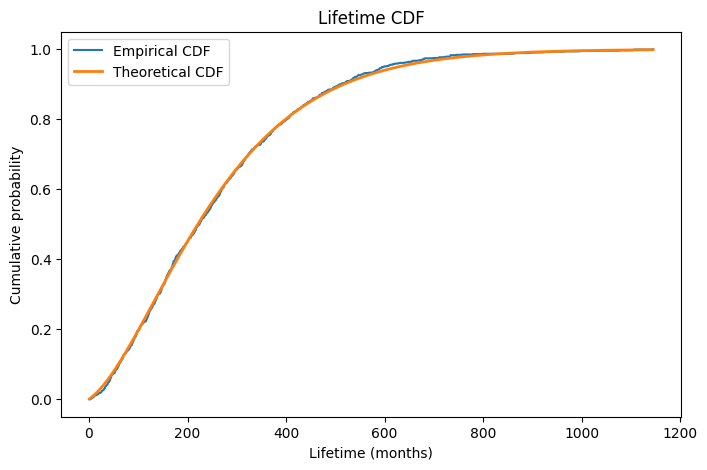

In [10]:
# We start by extracting Ps and ps
Ps = P[:4, :4]
ps = P[:4, 4]

pi = np.array([1,0,0,0])

# Theoretical probability mass function
def theoretical_pmf(t):

    return pi @ np.linalg.matrix_power(Ps,t) @ ps

# PMF and CDF comparison
def pmf_and_cdf(lifetimes):

    max_t = max(lifetimes)

    # Theoretical PMF
    theoretical_pmf_values = np.array([theoretical_pmf(t)for t in range(max_t)])

    print("Theoretical PMF sum:")
    print(theoretical_pmf_values.sum())

    # Theoretical cdf
    theoretical_cdf = np.cumsum(theoretical_pmf_values)

    # emprical pmf
    empirical_pmf = np.bincount(lifetimes)

    # Remove index 0 because nobody can die at month 0
    empirical_pmf = empirical_pmf[1:]

    empirical_pmf = empirical_pmf / empirical_pmf.sum()

    # Emperical cdf
    empirical_cdf = np.cumsum(empirical_pmf)

    # PMF plot
    plt.figure(figsize=(8,5))

    plt.plot(range(1, len(empirical_pmf)+1), empirical_pmf, alpha=0.6, label="Empirical PMF")

    plt.plot(range(1, len(theoretical_pmf_values)+1), theoretical_pmf_values, linewidth=2, label="Theoretical PMF")

    plt.xlabel("Lifetime (months)")
    plt.ylabel("Probability")
    plt.title("Lifetime PMF")
    plt.legend()

    plt.show()

    # CDF plot
    plt.figure(figsize=(8,5))

    plt.plot(range(1, len(empirical_cdf)+1), empirical_cdf, label="Empirical CDF")

    plt.plot(range(1, len(theoretical_cdf)+1), theoretical_cdf, linewidth=2, label="Theoretical CDF")

    plt.xlabel("Lifetime (months)")
    plt.ylabel("Cumulative probability")
    plt.title("Lifetime CDF")
    plt.legend()

    plt.show()

pmf_and_cdf(lifetimes)

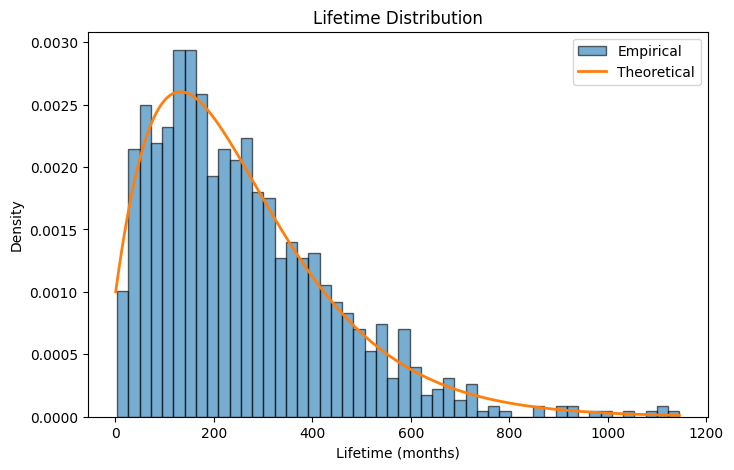

In [ ]:
# Histrogram comparison plot
def histogram_comparison(lifetimes):

    max_t = max(lifetimes)

    theoretical = np.array([theoretical_pmf(t)for t in range(max_t)])

    plt.figure(figsize=(8,5))

    plt.hist(lifetimes, bins=50 ,density=True, alpha=0.6 ,label="Empirical", edgecolor = "black")

    plt.plot(range(1, max_t + 1), theoretical, linewidth=2, label="Theoretical")

    plt.xlabel("Lifetime (months)")
    plt.ylabel("Density")
    plt.title("Lifetime Distribution")
    plt.legend()

    plt.show()

histogram_comparison(lifetimes)

In [ ]:
# Chi-square test
def chi_square_3(lifetimes):

    max_t = max(lifetimes)

    theoretical_probs = np.array([theoretical_pmf(t)for t in range(max_t)])

    theoretical_probs /= theoretical_probs.sum()

    # 50-month bins
    bins = np.arange(0, max_t + 51, 50)

    observed, _ = np.histogram(lifetimes, bins=bins)

    expected = []

    for lower, upper in zip(bins[:-1], bins[1:]):

        # Lifetime=1 corresponds to theoretical index 0
        start = max(lower - 1, 0)
        stop = max(upper - 1, 0)

        prob = theoretical_probs[start:stop].sum()

        expected.append(prob * len(lifetimes))

    expected = np.array(expected)

    # Normalize to make sums match
    expected *= observed.sum() / expected.sum()

    chi2, pvalue = chisquare(observed, expected)

    print("Chi-square statistic:", chi2)
    print("p-value:", pvalue)

    return chi2, pvalue

chi2, pvalue = chi_square_3(lifetimes)

Chi-square statistic: 20.825363787594583
p-value: 0.5315523459630649


### Task 4

In [16]:
# We need to reach 1000 acceptable simulations
n_accept=1000

def expected_lifetime(P, n_accept):

    accepted = []

    while len(accepted) < n_accept:

        life, _, trajectory = simulate_woman(P)

        first_year = trajectory[:13]

        # Check that the woman survived 12 months
        survived_12_months = len(first_year) > 12

        # Check if rappearance happens within 12 months
        recurrence = any(s in [1,2,3]for s in first_year)

        # Accept if both requirements are met
        if survived_12_months and recurrence:
            accepted.append(life)

    accepted = np.array(accepted)

    # Take the mean to find estimate
    estimate = np.mean(accepted)

    print("Expected lifetime:", estimate)

    return estimate

estimate = expected_lifetime(P, n_accept)

Expected lifetime: 172.467


### Task 5

In [17]:
# Crude Monte Carlo
def estimate_fraction(P):

    lifetimes = []

    # Simulate 200 women
    for _ in range(200):

        life, _, _ = simulate_woman(P)

        lifetimes.append(life)

    lifetimes = np.array(lifetimes)

    # Convert to indicator (true/false)
    indicator = np.mean(lifetimes <= 350)

    mean_lifetime = np.mean(lifetimes)

    return indicator, mean_lifetime


# The known mean lifetime - theoretical mean
def theoretical_mean():

    pi = np.array([1,0,0,0])

    I = np.eye(4)

    ones = np.ones(4)

    return pi @ np.linalg.inv(I-Ps) @ ones

In [ ]:
# Main
# Estimates the probability that a woman dies within 350 months
def fraction_of_women(P):

    crude = []
    controls = []

    # Theoretical mean lifetime
    true_mean = theoretical_mean()

    # Repeat 100 times
    for _ in range(100):

        # Estimate fraction dying within 350 months
        estimate, sample_mean = estimate_fraction(P)

        crude.append(estimate)
        controls.append(sample_mean)

    crude = np.array(crude)
    controls = np.array(controls)

    # Estimate the optimal control variate coefficient
    # beta = Cov(Y,X) / Var(X)
    beta = np.cov(crude, controls)[0,1] / np.var(controls)

    # Construct the control variate estimator
    # Y_cv = Y - beta(X - E[X])
    adjusted = crude - beta*(controls - true_mean)

    # Estimated fraction
    fraction = np.mean(adjusted)

    # Variances
    crude_variance = np.var(crude)
    reduced_variance = np.var(adjusted)

    print("Estimated fraction dying within 350 months:")
    print(fraction)

    print("\nCrude variance:")
    print(crude_variance)

    print("\nReduced variance:")
    print(reduced_variance)

    return fraction, crude_variance, reduced_variance

crude, crude_variance, reduced_variance = fraction_of_women(P)

Estimated fraction dying within 350 months:
0.7392945700006393

Crude variance:
0.0007916275000000009

Reduced variance:
0.0003004759578463955


## Part 2: A continuous-time model

### Task 7

In [ ]:
# Transition-rate matrix
Q = np.array([
    [-0.0085, 0.005,   0.0025,  0,      0.001],
    [0,       -0.014,  0.005,   0.004,  0.005],
    [0,       0,       -0.008,  0.003,  0.005],
    [0,       0,       0,       -0.009, 0.009],
    [0,       0,       0,       0,      0.0]
])

# simulate one women using the ctmc model
def simulate_ctmc_woman(Q):

    # Initialize state
    state = 0

    current_time = 0

    trajectory = [(0,state)]

    # Continue until the absorbing state is reached
    while state != 4:

        rate = -Q[state,state]

        sojourn = np.random.exponential(scale=1/rate)

        current_time += sojourn

        # Convert rates into transition probabilities
        probs = Q[state].copy()

        # Remove diagonal entry
        probs[state] = 0

        probs = probs/rate

        # Simulate next state
        next_state = np.random.choice(5,p=probs)

        state = next_state

        trajectory.append((current_time,state))

    lifetime = current_time

    return lifetime, trajectory

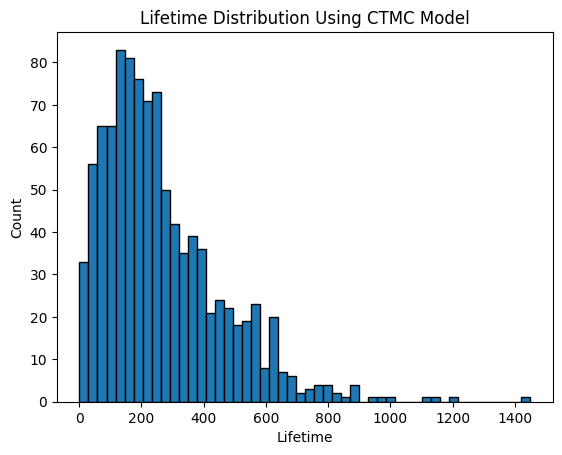

In [20]:
# Now we simulate 1000 women
lifetimes = []

for _ in range(1000):

    life,_ = simulate_ctmc_woman(Q)

    lifetimes.append(life)

lifetimes = np.array(lifetimes)

# Plot histrogram
plt.hist(lifetimes, bins=50, edgecolor = "black")
plt.xlabel("Lifetime")
plt.ylabel("Count")
plt.title("Lifetime Distribution Using CTMC Model")
plt.show()

In [21]:
# Mean and confidence interval
mean_life = np.mean(lifetimes)
se = np.std(lifetimes,ddof=1)/np.sqrt(1000)

lower = mean_life - 1.96*se
upper = mean_life + 1.96*se

print("Mean lifetime:", mean_life)
print("95% confidence interval:")
print(f"({lower:.3f}, {upper:.3f})")

Mean lifetime: 264.90603806260947
95% confidence interval:
(253.060, 276.752)


In [25]:
# Standard deviation and confidence interval
sd = np.std(lifetimes,ddof=1)

n = len(lifetimes)

lower_sd = np.sqrt((n-1)*sd**2/chi2.ppf(0.975,n-1))

upper_sd = np.sqrt((n-1)*sd**2/chi2.ppf(0.025,n-1))

print("Mean sd:", sd)
print("95% confidence interval:")
print(f"({lower_sd:.3f}, {upper_sd:.3f})")

Mean sd: 191.1312559875938
95% confidence interval:
(183.106, 199.898)


In [26]:
# Distant recurrence up until 30.5 months

# Proportion that have entered state 3 or 4 after 30.5 months
def distant_by_30_5(trajectory):

    for t,state in trajectory:

        # Only the time between 0 and 30.5 months
        if t <= 30.5 and state in [2,3]:
            return True

    return False

# Run
count = 0

for _ in range(1000):

    _,traj = simulate_ctmc_woman(Q)

    if distant_by_30_5(traj):
        count += 1

print("Fraction of women whose distant recurrence occurs before 30.5 months:")
print(count/1000)

Fraction of women whose distant recurrence occurs before 30.5 months:
0.092


In [28]:
# Distant recurrence after 30.5 months

# Run
count = 0

for _ in range(1000):

    _, trajectory = simulate_ctmc_woman(Q)

    for t, state in trajectory:

        if state in [2,3]:

            if t >= 30.5:

                count += 1

            break

print("Fraction of women whose distant recurrence occurs after 30.5 months:")
print(count/1000)

Fraction of women whose distant recurrence occurs after 30.5 months:
0.62


### Task 8

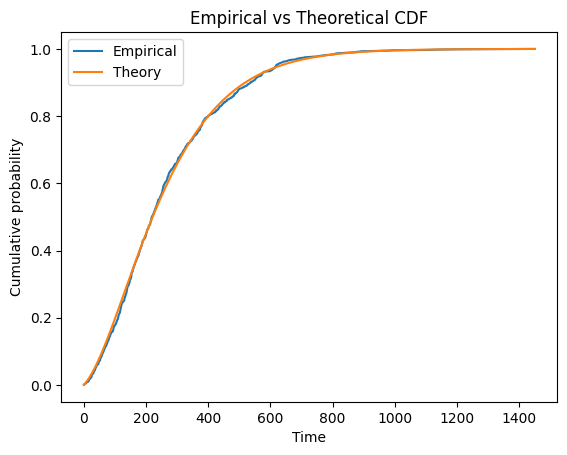

In [29]:
# Theoretical cdf
Qs = Q[:4,:4]

p0 = np.array([1,0,0,0])

ones = np.ones(4)

def theoretical_cdf(t):

    return (1 - p0 @ expm(Qs*t) @ ones)

# Compare to empirical
lifetimes_sorted = np.sort(lifetimes)

empirical_cdf = np.arange(1,len(lifetimes)+1)/(len(lifetimes))

# Plot comparison
plt.plot(lifetimes_sorted,empirical_cdf,label="Empirical")
grid = np.linspace(0,max(lifetimes),500)
plt.plot(grid,[theoretical_cdf(t)for t in grid],label="Theory")
plt.xlabel("Time")
plt.ylabel("Cumulative probability")
plt.title("Empirical vs Theoretical CDF")
plt.legend()
plt.show()

### Task 9

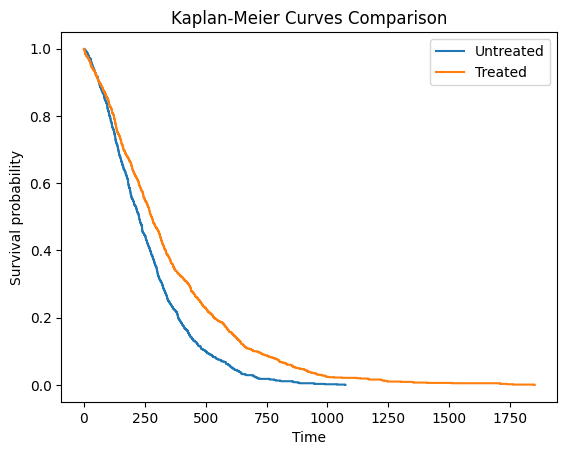

In [30]:
# New transition rate matrix
Q2 = np.array([
[-0.00475, 0.0025, 0.00125, 0,      0.001],
[0,        -0.007, 0,       0.002,  0.005],
[0,        0,      -0.008,  0.003,  0.005],
[0,        0,      0,       -0.009, 0.009],
[0,        0,      0,       0,      0]
])

# Kaplan-Meier curve
# We simulate 1000 lifetimes
treated = [simulate_ctmc_woman(Q2)[0]for _ in range(1000)]

untreated = [simulate_ctmc_woman(Q)[0]for _ in range(1000)]

# Kaplan-Meier estimate
def km_curve(lifetimes):

    lifetimes = np.sort(lifetimes)

    n = len(lifetimes)

    survival = []

    times = []

    for i,t in enumerate(lifetimes):

        survival.append((n-i-1)/n)

        times.append(t)

    return times,survival

# Plot
t1,s1 = km_curve(untreated)
t2,s2 = km_curve(treated)

plt.step(t1,s1,where='post',label='Untreated')
plt.step(t2,s2,where='post',label='Treated')
plt.ylabel("Survival probability")
plt.xlabel("Time")
plt.title("Kaplan-Meier Curves Comparison")
plt.legend()
plt.show()

## Part 3: Estimation

### Task 12

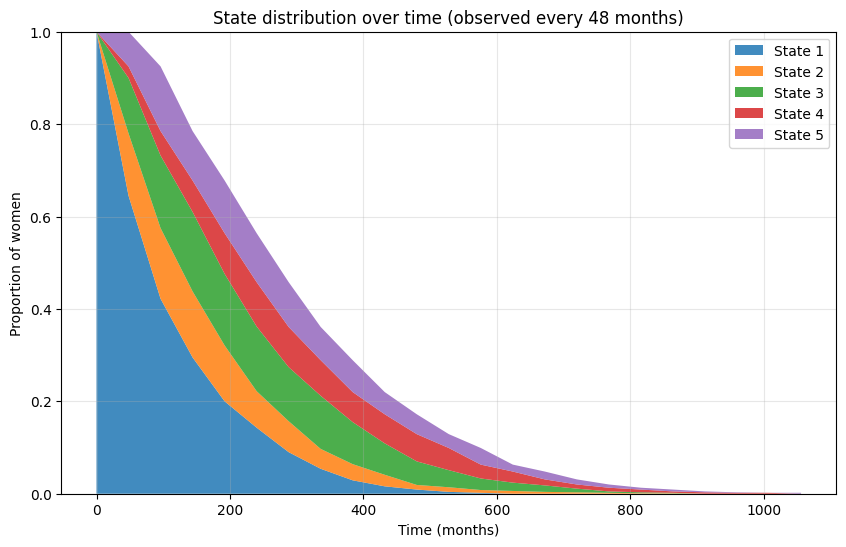

In [43]:
# Set parameters
# Matrix used is the first Q matrix
n_women = 1000
death_state = 4
dt = 48  # Months

all_paths = []

for _ in range(n_women):

    state = 0
    t = 0.0

    event_times = []
    event_states = []

    # Simulate CTMC path
    while state != death_state:

        rate = -Q[state, state]
        t += np.random.exponential(1 / rate)

        probs = Q[state].copy()
        probs[state] = 0
        probs = probs / probs.sum()

        state = np.random.choice([0, 1, 2, 3, 4], p=probs)

        event_times.append(t)
        event_states.append(state)

    # Sample every 48 months
    Y = []
    t_obs = 0

    while True:
        idx = np.searchsorted(event_times, t_obs, side="right") - 1

        if idx < 0:
            current = 0
        else:
            current = event_states[idx]

        Y.append(current)

        if current == death_state:
            break

        t_obs += dt

    all_paths.append(Y)


# Build state proportions over time
max_len = max(len(p) for p in all_paths)
counts = np.zeros((5, max_len))

for path in all_paths:
    for t, s in enumerate(path):
        counts[s, t] += 1

proportions = counts / n_women


# Plot
time = np.arange(max_len) * dt

plt.figure(figsize=(10, 6))

plt.stackplot(
    time,
    proportions[0],
    proportions[1],
    proportions[2],
    proportions[3],
    proportions[4],
    labels=[f"State {i+1}" for i in range(5)],
    alpha=0.85
)

plt.xlabel("Time (months)")
plt.ylabel("Proportion of women")
plt.title("State distribution over time (observed every 48 months)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.ylim(0, 1)

plt.show()

### Task 13

Estimated Q:
 [[-0.00851   0.005047  0.00257   0.000136  0.000757]
 [ 0.       -0.014559  0.00518   0.003511  0.005868]
 [ 0.        0.       -0.00842   0.002839  0.00558 ]
 [ 0.        0.        0.       -0.008822  0.008822]
 [ 0.        0.        0.        0.       -0.      ]]

True Q:
 [[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]


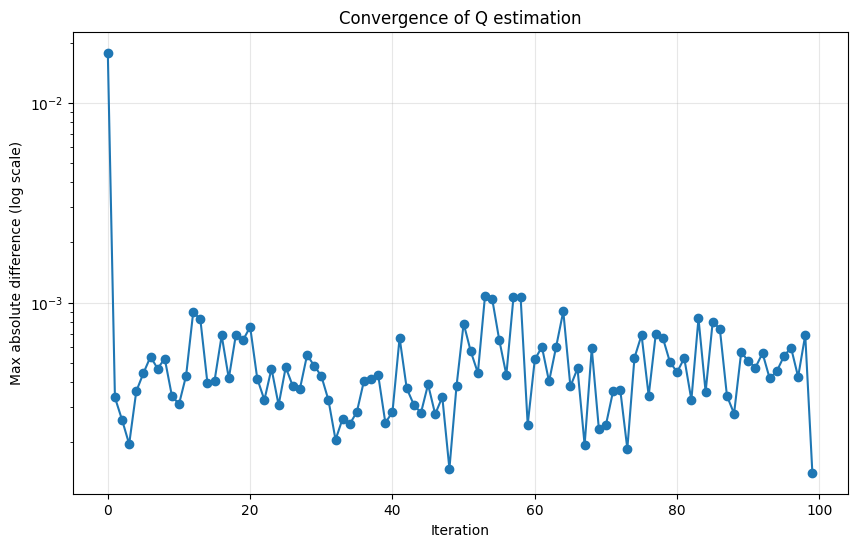

In [ ]:
# Intial estimation of Q
n_states = 5
Qest = np.random.rand(n_states, n_states) * 0.01

# Ensure each row sums to 0
for i in range(n_states):
    Qest[i, i] = -Qest[i].sum() + Qest[i, i]

max_iter = 100
tol = 1e-4
diffs = []

# Simulate ctmc path using current estimate of Q
def simulate_path(start, Q, interval, death_state):
    current = start
    time = 0.0

    jump_times = []
    jump_states = []

    # Simulate until time limit is reached or we reach absorbing state
    while time < interval and current != death_state:
        rate = -Q[current, current]
        if rate <= 0:
            break

        dt = np.random.exponential(1 / rate)

        if time + dt > interval:
            break

        time += dt

        probs = Q[current].copy()
        probs[current] = 0.0
        probs = probs / probs.sum()

        next_state = np.random.choice(np.arange(len(Q)), p=probs)

        jump_times.append(time)
        jump_states.append(next_state)

        current = next_state

    return jump_times, jump_states, current


# EM loop to estimate Q
for iteration in range(max_iter):

    N = np.zeros((n_states, n_states))
    S = np.zeros(n_states)

    # Process all observed trajectories
    for obs in observations:
        for k in range(len(obs) - 1):

            start = obs[k]
            end = obs[k + 1]

            if start == death_state:
                S[death_state] += interval
                continue

            # Rejection sampling 
            accepted = False
            while not accepted:
                jump_times, jump_states, final_state = simulate_path(
                    start, Q_est, interval, death_state
                )
                accepted = (final_state == end)

            # Accumulate statistics from the simulated path
            prev_t = 0.0
            current = start

            for t, s in zip(jump_times, jump_states):
                S[current] += (t - prev_t)
                N[current, s] += 1
                current = s
                prev_t = t

            S[current] += (interval - prev_t)

    # Update Q using N and S
    Qnew = np.zeros((n_states, n_states))

    for i in range(n_states):
        if S[i] > 0:
            for j in range(n_states):
                if i != j:
                    Qnew[i, j] = N[i, j] / S[i]
        Qnew[i, i] = -np.sum(Qnew[i])

    # Convergende check
    diff = np.max(np.abs(Qnew - Qest))
    diffs.append(diff)

    Qest = Qnew

    if diff < tol:
        break


# Results
np.set_printoptions(precision=6, suppress=True)

print("Estimated Q:\n", Qest)
print("\nTrue Q:\n", Q)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(diffs, marker='o')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Max absolute difference (log scale)')
plt.title('Convergence of Q estimation')
plt.grid(True, alpha=0.3)
plt.show()